# Прогноз спроса на 2025 год: demand proxy + SARIMAX

Ноутбук строит `demand_proxy_index`, обучает фиксированную модель `SARIMAX(0,1,1)(0,1,1,4)`, прогнозирует спрос на 2025 год и валидирует прогноз по фактическому 2025 году.

Сохрани содержимое этого JSON в файл `demand_forecast_sarimax_colab.ipynb` и открой его в Colab.

In [2]:
!pip -q install statsmodels openpyxl xlrd

from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings('ignore')

try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    pass

BASE_DIR = Path('/content/drive/MyDrive/rostat')
OUT_DIR = BASE_DIR / 'demand_forecast_2025'
PLOTS_DIR = OUT_DIR / 'plots'
OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

BEST_ORDER = (0, 1, 1)
BEST_SEASONAL_ORDER = (0, 1, 1, 4)
TRAIN_END = pd.Timestamp('2024-12-31')
TEST_YEAR = 2025
TARGET_COL = 'demand_proxy_index'
GOODS_GROUPS = ['G01', 'G02', 'G03', 'G04', 'G05', 'G07', 'G99']
print('OUT_DIR:', OUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
OUT_DIR: /content/drive/MyDrive/rostat/demand_forecast_2025


In [3]:
def find_existing_file(paths):
    for p in paths:
        p = Path(p)
        if p.exists():
            return p
    return None

DATASET_PATH = find_existing_file([
    BASE_DIR / 'quarterly_model_selection_staged' / 'quarterly_model_dataset_with_demand_proxy.csv',
    BASE_DIR / 'quarterly_model_selection_staged' / 'quarterly_model_dataset_enriched_fixed.csv',
    BASE_DIR / 'quarterly_model_selection_staged' / 'quarterly_model_dataset_enriched.csv',
    BASE_DIR / 'quarterly_model_selection_staged' / 'quarterly_model_dataset.csv',
])

if DATASET_PATH is None:
    raise FileNotFoundError('Не найден квартальный датасет в /content/drive/MyDrive/rostat/quarterly_model_selection_staged/')

quarterly_data = pd.read_csv(DATASET_PATH, parse_dates=['period_end'])
quarterly_data['period_end'] = pd.to_datetime(quarterly_data['period_end']).dt.normalize()
quarterly_data = quarterly_data.sort_values(['product_group_code', 'period_end']).reset_index(drop=True)
print('Loaded:', DATASET_PATH)
print('Shape:', quarterly_data.shape)
display(quarterly_data.head())

Loaded: /content/drive/MyDrive/rostat/quarterly_model_selection_staged/quarterly_model_dataset_enriched.csv
Shape: (360, 63)


,product_group_code,product_group_name,period_end,year,quarter,mean_price,median_price,n_price_products,n_price_observations,sales_quarter_thousand_rub,...,shock_2022_q2,shock_2022_h2,post_2022,real_sales_proxy,real_sales_proxy_index,real_sales_proxy_index_lag1,real_sales_proxy_index_lag2,real_sales_proxy_index_lag4,stock_pressure,stock_to_sales_proxy
0,G01,"Хлеб, крупы, мука и макаронные изделия",2016-03-31,2016,1,65.201042,65.570,8.0,96.0,NaN,...,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,G01,"Хлеб, крупы, мука и макаронные изделия",2016-06-30,2016,2,67.253462,66.090,8.0,104.0,NaN,...,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,G01,"Хлеб, крупы, мука и макаронные изделия",2016-09-30,2016,3,68.782788,66.115,8.0,104.0,NaN,...,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,G01,"Хлеб, крупы, мука и макаронные изделия",2016-12-31,2016,4,68.152308,65.675,8.0,104.0,NaN,...,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,G01,"Хлеб, крупы, мука и макаронные изделия",2017-03-31,2017,1,67.500104,65.115,8.0,96.0,2.617199e+08,...,0,0,0,100.698764,100.0,NaN,NaN,NaN,NaN,NaN


In [4]:
def make_index_from_first_valid(x):
    x = x.astype(float)
    valid = x.dropna()
    if len(valid) == 0:
        return pd.Series(np.nan, index=x.index)
    base = valid.iloc[0]
    if pd.isna(base) or base == 0:
        return pd.Series(np.nan, index=x.index)
    return x / base * 100

required = ['product_group_code', 'product_group_name', 'period_end', 'year', 'quarter', 'sales_index', 'price_index']
missing_required = [c for c in required if c not in quarterly_data.columns]
if missing_required:
    raise ValueError(f'В датасете нет обязательных колонок: {missing_required}')

if 'price_index_original' not in quarterly_data.columns:
    quarterly_data['price_index_original'] = quarterly_data['price_index']

if 'price_index_filled' not in quarterly_data.columns:
    quarterly_data['price_index_filled'] = quarterly_data.groupby('product_group_code')['price_index'].transform(lambda s: s.interpolate(method='linear', limit_direction='both'))

if 'real_sales_proxy_index_filled' not in quarterly_data.columns:
    quarterly_data['real_sales_proxy_filled'] = quarterly_data['sales_index'] / quarterly_data['price_index_filled'] * 100
    quarterly_data['real_sales_proxy_index_filled'] = quarterly_data.groupby('product_group_code')['real_sales_proxy_filled'].transform(make_index_from_first_valid)

if 'is_interpolated_2021' not in quarterly_data.columns:
    quarterly_data['is_interpolated_2021'] = (quarterly_data['year'] == 2021).astype(int)
if 'shock_2022_q1' not in quarterly_data.columns:
    quarterly_data['shock_2022_q1'] = ((quarterly_data['year'] == 2022) & (quarterly_data['quarter'] == 1)).astype(int)
if 'shock_2022_q2' not in quarterly_data.columns:
    quarterly_data['shock_2022_q2'] = ((quarterly_data['year'] == 2022) & (quarterly_data['quarter'] == 2)).astype(int)
if 'shock_2022_h2' not in quarterly_data.columns:
    quarterly_data['shock_2022_h2'] = ((quarterly_data['year'] == 2022) & quarterly_data['quarter'].isin([3, 4])).astype(int)
if 'post_2022' not in quarterly_data.columns:
    quarterly_data['post_2022'] = (quarterly_data['period_end'] >= pd.Timestamp('2022-03-31')).astype(int)
if 'quarter_sin' not in quarterly_data.columns:
    quarterly_data['quarter_sin'] = np.sin(2 * np.pi * quarterly_data['quarter'] / 4)
if 'quarter_cos' not in quarterly_data.columns:
    quarterly_data['quarter_cos'] = np.cos(2 * np.pi * quarterly_data['quarter'] / 4)

display(quarterly_data.groupby(['product_group_code', 'product_group_name']).agg(n_periods=('period_end', 'nunique'), sales_index_non_null=('sales_index', lambda x: x.notna().sum()), price_index_filled_non_null=('price_index_filled', lambda x: x.notna().sum()), real_sales_proxy_non_null=('real_sales_proxy_index_filled', lambda x: x.notna().sum())).reset_index())

,product_group_code,product_group_name,n_periods,sales_index_non_null,price_index_filled_non_null,real_sales_proxy_non_null
0,G01,"Хлеб, крупы, мука и макаронные изделия",40,36,40,36
1,G02,Молочная продукция и яйца,40,36,40,36
2,G03,"Мясо, птица, рыба и колбасные изделия",40,36,40,36
3,G04,"Овощи, фрукты и картофель",40,36,40,36
4,G05,"Бакалея, масло, сахар, чай, соль",40,36,40,36
5,G07,"Товары для дома, гигиены и бытовая химия",40,36,40,36
6,G10,Топливо и транспортные товары,40,36,40,36
7,G11,Услуги,40,0,40,0
8,G99,Прочее,40,36,40,36


In [5]:
model_base = quarterly_data[quarterly_data['product_group_code'].isin(GOODS_GROUPS)].copy()
model_base = model_base.sort_values(['product_group_code', 'period_end']).reset_index(drop=True)
model_base['q_observed_proxy'] = model_base['real_sales_proxy_index_filled']
model_base['price_rel'] = model_base['price_index_filled'] / 100
model_base['log_q_obs'] = np.log(model_base['q_observed_proxy'].clip(lower=1e-6))
model_base['log_price'] = np.log(model_base['price_rel'].clip(lower=1e-6))

if 'stock_days_mean' in model_base.columns:
    pre_shock = model_base['year'].between(2017, 2021)
    normal_stock = model_base.loc[pre_shock].groupby('product_group_code')['stock_days_mean'].median().to_dict()
    model_base['normal_stock_days'] = model_base['product_group_code'].map(normal_stock)
    model_base['stock_shortage'] = (model_base['normal_stock_days'] - model_base['stock_days_mean']).clip(lower=0)
else:
    model_base['normal_stock_days'] = np.nan
    model_base['stock_shortage'] = 0.0

model_base['time_idx'] = model_base.groupby('product_group_code').cumcount()
coef_rows = []
demand_parts = []

for group_code, g in model_base.groupby('product_group_code'):
    g = g.copy().sort_values('period_end').reset_index(drop=True)
    train_corr = g[g['period_end'] <= TRAIN_END].copy()
    corr_cols = ['log_q_obs', 'log_price', 'stock_shortage', 'quarter', 'time_idx', 'shock_2022_q1', 'shock_2022_q2', 'shock_2022_h2', 'post_2022']
    corr_data = train_corr[corr_cols].dropna()

    if len(corr_data) < 20:
        beta_raw = np.nan
        delta_raw = np.nan
        beta_used = 0.0
        delta_used = 0.0
        r2 = np.nan
    else:
        X = corr_data[['log_price', 'stock_shortage', 'time_idx', 'shock_2022_q1', 'shock_2022_q2', 'shock_2022_h2', 'post_2022']].copy()
        q_dummies = pd.get_dummies(corr_data['quarter'].astype(int), prefix='q', drop_first=True)
        X = pd.concat([X, q_dummies], axis=1)
        X = sm.add_constant(X, has_constant='add')
        y = corr_data['log_q_obs']
        ols = sm.OLS(y, X).fit()
        beta_raw = ols.params.get('log_price', np.nan)
        delta_raw = ols.params.get('stock_shortage', np.nan)
        beta_used = min(beta_raw, 0) if pd.notna(beta_raw) else 0.0
        delta_used = min(delta_raw, 0) if pd.notna(delta_raw) else 0.0
        r2 = ols.rsquared

    g['log_demand_proxy'] = g['log_q_obs'] - beta_used * g['log_price'] - delta_used * g['stock_shortage'].fillna(0)
    g['demand_proxy_raw'] = np.exp(g['log_demand_proxy'])
    valid = g['demand_proxy_raw'].dropna()
    g['demand_proxy_index'] = g['demand_proxy_raw'] / valid.iloc[0] * 100 if len(valid) > 0 else np.nan

    coef_rows.append({'product_group_code': group_code, 'product_group_name': g['product_group_name'].iloc[0], 'n_obs_correction_train': len(corr_data), 'beta_price_raw': beta_raw, 'beta_price_used': beta_used, 'delta_shortage_raw': delta_raw, 'delta_shortage_used': delta_used, 'r2_correction': r2})
    demand_parts.append(g)

df_demand = pd.concat(demand_parts, ignore_index=True)
demand_coefficients = pd.DataFrame(coef_rows)

merge_cols = ['product_group_code', 'period_end', 'q_observed_proxy', 'normal_stock_days', 'stock_shortage', 'demand_proxy_raw', 'demand_proxy_index']
quarterly_data = quarterly_data.drop(columns=[c for c in merge_cols if c in quarterly_data.columns and c not in ['product_group_code', 'period_end']], errors='ignore')
quarterly_data = quarterly_data.merge(df_demand[merge_cols], on=['product_group_code', 'period_end'], how='left')

for lag in [1, 2, 4]:
    quarterly_data[f'demand_proxy_index_lag{lag}'] = quarterly_data.groupby('product_group_code')['demand_proxy_index'].shift(lag)

quarterly_data.to_csv(OUT_DIR / 'quarterly_dataset_with_demand_proxy.csv', index=False, encoding='utf-8-sig')
demand_coefficients.to_csv(OUT_DIR / 'demand_proxy_correction_coefficients.csv', index=False, encoding='utf-8-sig')
display(demand_coefficients)

,product_group_code,product_group_name,n_obs_correction_train,beta_price_raw,beta_price_used,delta_shortage_raw,delta_shortage_used,r2_correction
0,G01,"Хлеб, крупы, мука и макаронные изделия",0,NaN,0.0,NaN,0.0,NaN
1,G02,Молочная продукция и яйца,0,NaN,0.0,NaN,0.0,NaN
2,G03,"Мясо, птица, рыба и колбасные изделия",0,NaN,0.0,NaN,0.0,NaN
3,G04,"Овощи, фрукты и картофель",0,NaN,0.0,NaN,0.0,NaN
4,G05,"Бакалея, масло, сахар, чай, соль",0,NaN,0.0,NaN,0.0,NaN
5,G07,"Товары для дома, гигиены и бытовая химия",0,NaN,0.0,NaN,0.0,NaN
6,G99,Прочее,0,NaN,0.0,NaN,0.0,NaN


In [6]:
BASE_EXOG_CANDIDATES = ['quarter_sin', 'quarter_cos', 'is_interpolated_2021', 'shock_2022_q1', 'shock_2022_q2', 'shock_2022_h2', 'post_2022']

def safe_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred) & (np.abs(y_true) > 1e-9)
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.sum() else np.nan

def safe_smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = np.isfinite(y_true) & np.isfinite(y_pred) & (denom > 1e-9)
    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100 if mask.sum() else np.nan

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    return np.sqrt(np.mean((y_true[mask] - y_pred[mask]) ** 2)) if mask.sum() else np.nan

def get_group_exog_columns(g):
    train = g[g['period_end'] <= TRAIN_END]
    test = g[g['year'] == TEST_YEAR]
    cols = []
    for c in BASE_EXOG_CANDIDATES:
        if c in g.columns and train[c].notna().all() and test[c].notna().all() and train[c].nunique(dropna=True) > 1:
            cols.append(c)
    return cols

def fit_best_sarimax(y_train, X_train=None):
    try:
        model = SARIMAX(y_train, exog=X_train, order=BEST_ORDER, seasonal_order=BEST_SEASONAL_ORDER, enforce_stationarity=False, enforce_invertibility=False)
        result = model.fit(disp=False, maxiter=500)
        return result, 'SARIMAX(0,1,1)(0,1,1,4)'
    except Exception:
        model = SARIMAX(y_train, exog=X_train, order=(0, 1, 1), seasonal_order=(0, 0, 0, 0), enforce_stationarity=False, enforce_invertibility=False)
        result = model.fit(disp=False, maxiter=500)
        return result, 'fallback SARIMAX(0,1,1)'

model_df = quarterly_data[quarterly_data['product_group_code'].isin(GOODS_GROUPS)].copy().sort_values(['product_group_code', 'period_end']).reset_index(drop=True)
forecast_rows = []
metrics_rows = []
model_info_rows = []

for group_code, g in model_df.groupby('product_group_code'):
    g = g.copy().sort_values('period_end').reset_index(drop=True)
    train = g[(g['period_end'] <= TRAIN_END) & g[TARGET_COL].notna()].copy()
    test = g[(g['year'] == TEST_YEAR) & g[TARGET_COL].notna()].copy()

    if len(train) < 20 or len(test) == 0:
        metrics_rows.append({'product_group_code': group_code, 'product_group_name': g['product_group_name'].iloc[0], 'status': 'skipped_not_enough_data', 'n_train': len(train), 'n_test': len(test), 'mape': np.nan, 'smape': np.nan, 'rmse': np.nan})
        continue

    exog_cols = get_group_exog_columns(g)
    X_train = train[exog_cols] if exog_cols else None
    X_test = test[exog_cols] if exog_cols else None
    y_train = train[TARGET_COL].astype(float)

    result, model_name = fit_best_sarimax(y_train, X_train)
    pred = result.get_forecast(steps=len(test), exog=X_test)
    pred_mean = np.asarray(pred.predicted_mean, dtype=float)
    conf = pred.conf_int(alpha=0.20)
    lower = conf.iloc[:, 0].to_numpy(dtype=float) if isinstance(conf, pd.DataFrame) else np.asarray(conf)[:, 0].astype(float)
    upper = conf.iloc[:, 1].to_numpy(dtype=float) if isinstance(conf, pd.DataFrame) else np.asarray(conf)[:, 1].astype(float)

    metrics_rows.append({'product_group_code': group_code, 'product_group_name': g['product_group_name'].iloc[0], 'status': 'ok', 'model': model_name, 'exog_cols': ', '.join(exog_cols), 'n_train': len(train), 'n_test': len(test), 'mape': safe_mape(test[TARGET_COL], pred_mean), 'smape': safe_smape(test[TARGET_COL], pred_mean), 'rmse': rmse(test[TARGET_COL], pred_mean), 'aic': result.aic, 'bic': result.bic})
    model_info_rows.append({'product_group_code': group_code, 'product_group_name': g['product_group_name'].iloc[0], 'model': model_name, 'exog_cols': ', '.join(exog_cols), 'aic': result.aic, 'bic': result.bic, 'n_train': len(train)})

    for i, (_, row) in enumerate(test.iterrows()):
        actual = float(row[TARGET_COL])
        forecast = float(pred_mean[i])
        forecast_rows.append({'product_group_code': group_code, 'product_group_name': row['product_group_name'], 'period_end': row['period_end'], 'year': int(row['year']), 'quarter': int(row['quarter']), 'actual_demand_proxy_index': actual, 'forecast_demand_proxy_index': forecast, 'forecast_lower_80': float(lower[i]), 'forecast_upper_80': float(upper[i]), 'abs_error': abs(actual - forecast), 'ape': abs((actual - forecast) / actual) * 100 if actual != 0 else np.nan})

forecast_2025 = pd.DataFrame(forecast_rows)
validation_metrics = pd.DataFrame(metrics_rows)
model_info = pd.DataFrame(model_info_rows)

forecast_2025.to_csv(OUT_DIR / 'demand_forecast_2025_by_group.csv', index=False, encoding='utf-8-sig')
validation_metrics.to_csv(OUT_DIR / 'demand_forecast_2025_validation_metrics.csv', index=False, encoding='utf-8-sig')
model_info.to_csv(OUT_DIR / 'demand_forecast_2025_model_info.csv', index=False, encoding='utf-8-sig')

ok_metrics = validation_metrics[validation_metrics['status'].eq('ok')].copy()
summary_df = pd.DataFrame([{'n_groups': len(ok_metrics), 'mean_mape': ok_metrics['mape'].mean(), 'median_mape': ok_metrics['mape'].median(), 'mean_smape': ok_metrics['smape'].mean(), 'median_smape': ok_metrics['smape'].median(), 'mean_rmse': ok_metrics['rmse'].mean(), 'median_rmse': ok_metrics['rmse'].median()}])
summary_df.to_csv(OUT_DIR / 'demand_forecast_2025_validation_summary.csv', index=False, encoding='utf-8-sig')

display(validation_metrics.sort_values('mape'))
display(summary_df)
display(forecast_2025.head(20))

,product_group_code,product_group_name,status,model,exog_cols,n_train,n_test,mape,smape,rmse,aic,bic
2,G03,"Мясо, птица, рыба и колбасные изделия",ok,"SARIMAX(0,1,1)(0,1,1,4)","quarter_sin, quarter_cos, is_interpolated_2021...",32,4,2.176416,2.209813,3.107125,133.067025,143.512249
1,G02,Молочная продукция и яйца,ok,"SARIMAX(0,1,1)(0,1,1,4)","quarter_sin, quarter_cos, is_interpolated_2021...",32,4,3.133455,3.067095,4.034324,149.891178,160.336403
0,G01,"Хлеб, крупы, мука и макаронные изделия",ok,"SARIMAX(0,1,1)(0,1,1,4)","quarter_sin, quarter_cos, is_interpolated_2021...",32,4,3.137275,3.082437,4.335894,163.592240,174.037464
5,G07,"Товары для дома, гигиены и бытовая химия",ok,"SARIMAX(0,1,1)(0,1,1,4)","quarter_sin, quarter_cos, is_interpolated_2021...",32,4,4.811077,4.588045,12.586156,173.135892,183.581116
6,G99,Прочее,ok,"SARIMAX(0,1,1)(0,1,1,4)","quarter_sin, quarter_cos, is_interpolated_2021...",32,4,6.296384,5.978081,10.534051,166.209437,176.654662
4,G05,"Бакалея, масло, сахар, чай, соль",ok,"SARIMAX(0,1,1)(0,1,1,4)","quarter_sin, quarter_cos, is_interpolated_2021...",32,4,10.123922,9.616976,12.468350,147.391857,157.837081
3,G04,"Овощи, фрукты и картофель",ok,"SARIMAX(0,1,1)(0,1,1,4)","quarter_sin, quarter_cos, is_interpolated_2021...",32,4,18.774543,17.424233,23.059012,201.928946,212.374170


,n_groups,mean_mape,median_mape,mean_smape,median_smape,mean_rmse,median_rmse
0,7,6.921867,4.811077,6.566669,4.588045,10.017844,10.534051


,product_group_code,product_group_name,period_end,year,quarter,actual_demand_proxy_index,forecast_demand_proxy_index,forecast_lower_80,forecast_upper_80,abs_error,ape
0,G01,"Хлеб, крупы, мука и макаронные изделия",2025-03-31,2025,1,120.541266,122.640388,113.173674,132.107103,2.099122,1.741414
1,G01,"Хлеб, крупы, мука и макаронные изделия",2025-06-30,2025,2,119.769519,125.628340,115.210524,136.046156,5.858821,4.891747
2,G01,"Хлеб, крупы, мука и макаронные изделия",2025-09-30,2025,3,142.260315,146.994415,135.705346,158.283484,4.734100,3.327772
3,G01,"Хлеб, крупы, мука и макаронные изделия",2025-12-31,2025,4,144.857179,148.606324,136.508586,160.704063,3.749146,2.588167
4,G02,Молочная продукция и яйца,2025-03-31,2025,1,106.784244,109.423122,102.608283,116.237962,2.638879,2.471225
5,G02,Молочная продукция и яйца,2025-06-30,2025,2,101.156599,105.566321,97.779005,113.353636,4.409721,4.359302
6,G02,Молочная продукция и яйца,2025-09-30,2025,3,115.067570,121.277947,112.626794,129.929099,6.210377,5.397157
7,G02,Молочная продукция и яйца,2025-12-31,2025,4,115.477318,115.830835,106.394596,125.267074,0.353517,0.306136
8,G03,"Мясо, птица, рыба и колбасные изделия",2025-03-31,2025,1,103.821733,103.061944,98.513415,107.610473,0.759788,0.731820
9,G03,"Мясо, птица, рыба и колбасные изделия",2025-06-30,2025,2,110.833429,108.479685,103.282925,113.676446,2.353744,2.123677


Таблица прогноза:


,Код группы,Название группы,Период,Год,Квартал,Фактический proxy спроса,Прогноз proxy спроса,Нижняя граница 80% интервала,Верхняя граница 80% интервала,Абсолютная ошибка,"Абсолютная процентная ошибка (APE), %"
0,G01,"Хлеб, крупы, мука и макаронные изделия",2025-03-31,2025,1,120.541266,122.640388,113.173674,132.107103,2.099122,1.741414
1,G01,"Хлеб, крупы, мука и макаронные изделия",2025-06-30,2025,2,119.769519,125.628340,115.210524,136.046156,5.858821,4.891747
2,G01,"Хлеб, крупы, мука и макаронные изделия",2025-09-30,2025,3,142.260315,146.994415,135.705346,158.283484,4.734100,3.327772
3,G01,"Хлеб, крупы, мука и макаронные изделия",2025-12-31,2025,4,144.857179,148.606324,136.508586,160.704063,3.749146,2.588167
4,G02,Молочная продукция и яйца,2025-03-31,2025,1,106.784244,109.423122,102.608283,116.237962,2.638879,2.471225
5,G02,Молочная продукция и яйца,2025-06-30,2025,2,101.156599,105.566321,97.779005,113.353636,4.409721,4.359302
6,G02,Молочная продукция и яйца,2025-09-30,2025,3,115.067570,121.277947,112.626794,129.929099,6.210377,5.397157
7,G02,Молочная продукция и яйца,2025-12-31,2025,4,115.477318,115.830835,106.394596,125.267074,0.353517,0.306136
8,G03,"Мясо, птица, рыба и колбасные изделия",2025-03-31,2025,1,103.821733,103.061944,98.513415,107.610473,0.759788,0.731820
9,G03,"Мясо, птица, рыба и колбасные изделия",2025-06-30,2025,2,110.833429,108.479685,103.282925,113.676446,2.353744,2.123677


Таблица метрик:


,Код группы,Название группы,Статус,Модель,Экзогенные признаки,Число наблюдений train,Число наблюдений test,"MAPE, %","sMAPE, %",RMSE,AIC,BIC
2,G03,"Мясо, птица, рыба и колбасные изделия",ok,"SARIMAX(0,1,1)(0,1,1,4)","quarter_sin, quarter_cos, is_interpolated_2021...",32,4,2.176416,2.209813,3.107125,133.067025,143.512249
1,G02,Молочная продукция и яйца,ok,"SARIMAX(0,1,1)(0,1,1,4)","quarter_sin, quarter_cos, is_interpolated_2021...",32,4,3.133455,3.067095,4.034324,149.891178,160.336403
0,G01,"Хлеб, крупы, мука и макаронные изделия",ok,"SARIMAX(0,1,1)(0,1,1,4)","quarter_sin, quarter_cos, is_interpolated_2021...",32,4,3.137275,3.082437,4.335894,163.592240,174.037464
5,G07,"Товары для дома, гигиены и бытовая химия",ok,"SARIMAX(0,1,1)(0,1,1,4)","quarter_sin, quarter_cos, is_interpolated_2021...",32,4,4.811077,4.588045,12.586156,173.135892,183.581116
6,G99,Прочее,ok,"SARIMAX(0,1,1)(0,1,1,4)","quarter_sin, quarter_cos, is_interpolated_2021...",32,4,6.296384,5.978081,10.534051,166.209437,176.654662
4,G05,"Бакалея, масло, сахар, чай, соль",ok,"SARIMAX(0,1,1)(0,1,1,4)","quarter_sin, quarter_cos, is_interpolated_2021...",32,4,10.123922,9.616976,12.468350,147.391857,157.837081
3,G04,"Овощи, фрукты и картофель",ok,"SARIMAX(0,1,1)(0,1,1,4)","quarter_sin, quarter_cos, is_interpolated_2021...",32,4,18.774543,17.424233,23.059012,201.928946,212.374170


Сводка по качеству:


,Число групп,"Средний MAPE, %","Медианный MAPE, %","Средний sMAPE, %","Медианный sMAPE, %",Средний RMSE,Медианный RMSE
0,7,6.921867,4.811077,6.566669,4.588045,10.017844,10.534051


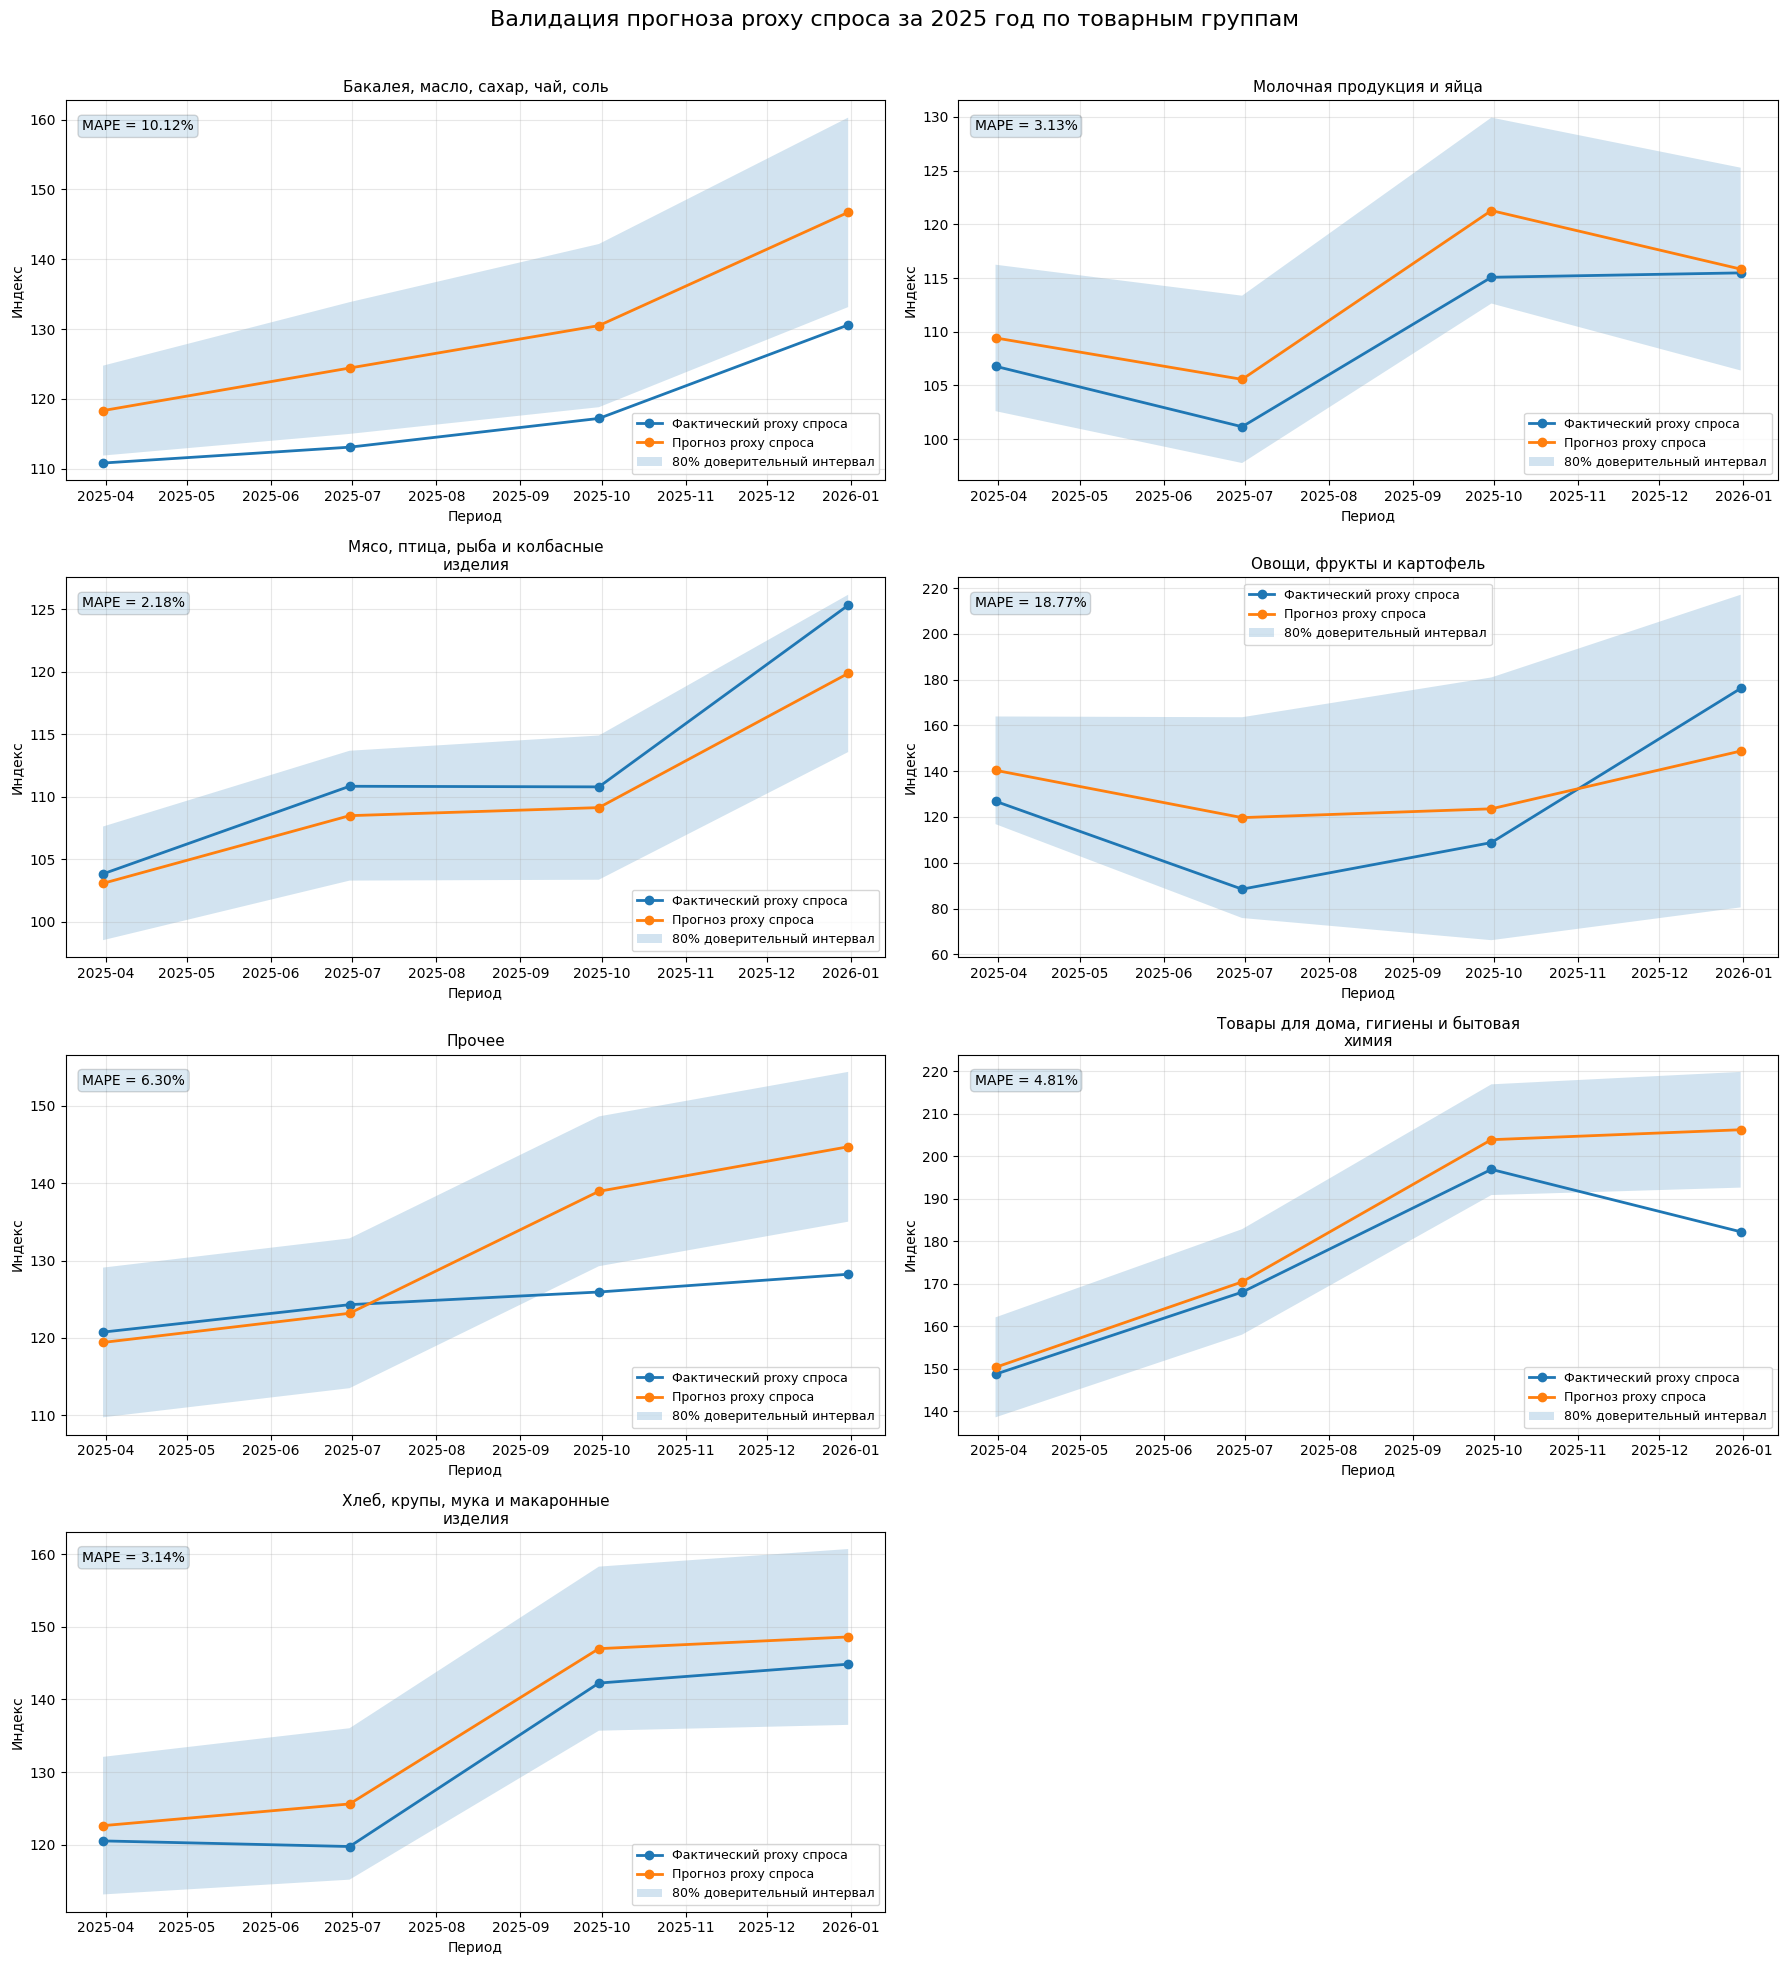

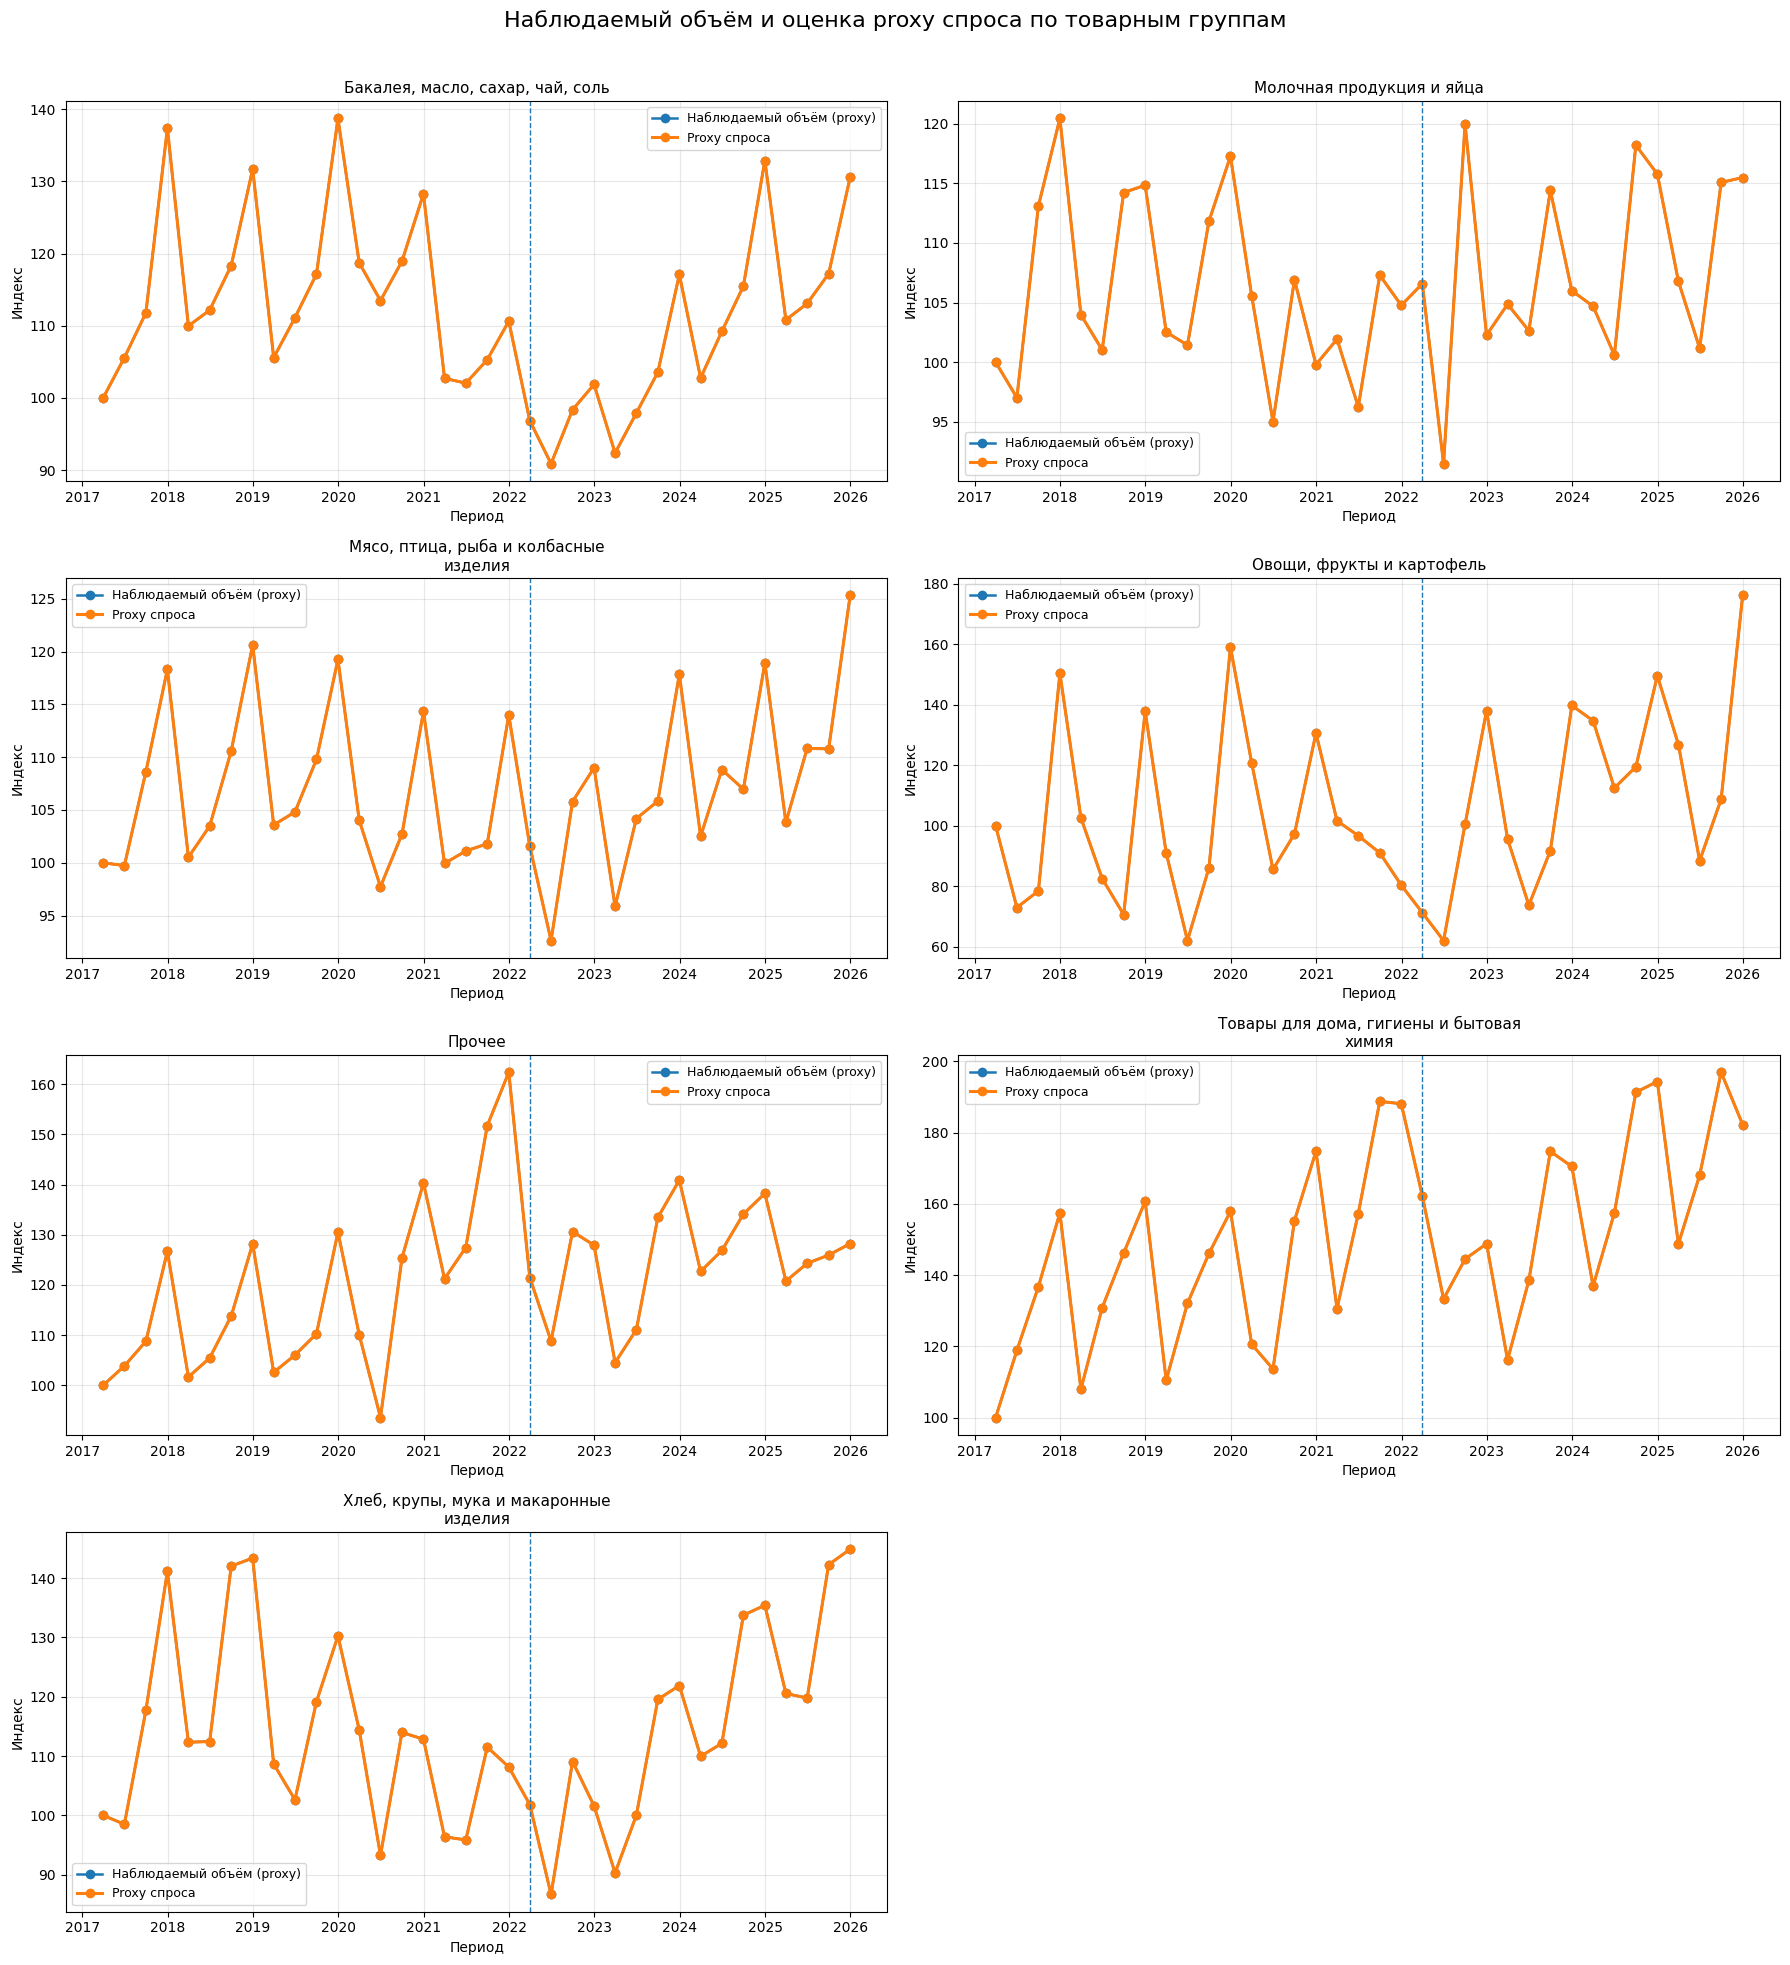

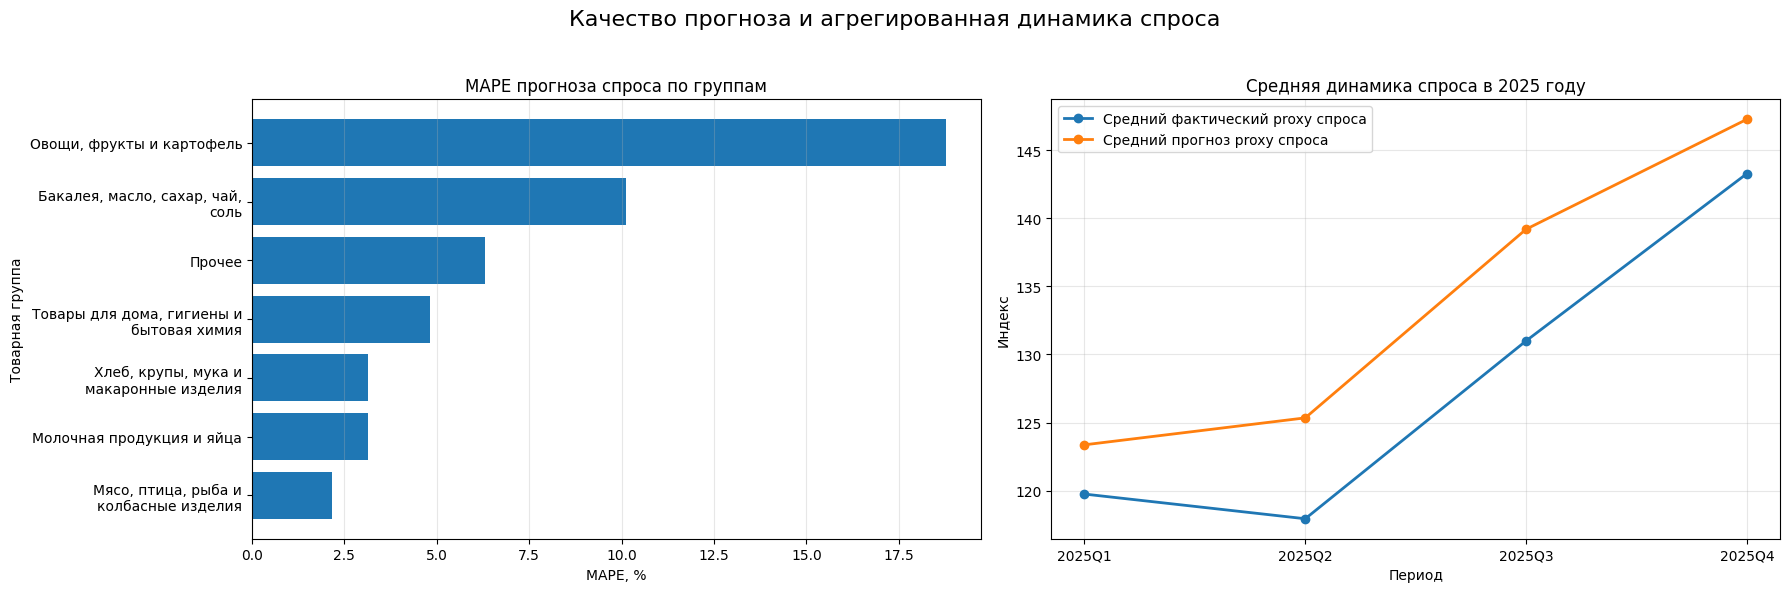

Готово. Сохранены файлы:
- /content/drive/MyDrive/rostat/demand_forecast_2025/quarterly_dataset_with_demand_proxy.csv
- /content/drive/MyDrive/rostat/demand_forecast_2025/demand_proxy_correction_coefficients.csv
- /content/drive/MyDrive/rostat/demand_forecast_2025/demand_forecast_2025_by_group.csv
- /content/drive/MyDrive/rostat/demand_forecast_2025/demand_forecast_2025_validation_metrics.csv
- /content/drive/MyDrive/rostat/demand_forecast_2025/demand_forecast_2025_validation_summary.csv
- /content/drive/MyDrive/rostat/demand_forecast_2025/demand_forecast_2025_model_info.csv
- /content/drive/MyDrive/rostat/demand_forecast_2025/прогноз_спроса_2025_по_группам.csv
- /content/drive/MyDrive/rostat/demand_forecast_2025/метрики_валидации_прогноза_спроса_2025.csv
- /content/drive/MyDrive/rostat/demand_forecast_2025/информация_о_моделях_sarimax.csv
- /content/drive/MyDrive/rostat/demand_forecast_2025/сводка_по_качеству_валидации.csv
- /content/drive/MyDrive/rostat/demand_forecast_2025/plots


In [8]:
# ============================================================
# 5. Красивые таблицы + общие холсты с несколькими графиками
# ============================================================

import math
from textwrap import fill

# -----------------------------
# 5.1. Русские названия таблиц
# -----------------------------

# Таблица прогноза
forecast_2025_ru = forecast_2025.rename(columns={
    "product_group_code": "Код группы",
    "product_group_name": "Название группы",
    "period_end": "Период",
    "year": "Год",
    "quarter": "Квартал",
    "actual_demand_proxy_index": "Фактический proxy спроса",
    "forecast_demand_proxy_index": "Прогноз proxy спроса",
    "forecast_lower_80": "Нижняя граница 80% интервала",
    "forecast_upper_80": "Верхняя граница 80% интервала",
    "abs_error": "Абсолютная ошибка",
    "ape": "Абсолютная процентная ошибка (APE), %",
})

# Таблица метрик
validation_metrics_ru = validation_metrics.rename(columns={
    "product_group_code": "Код группы",
    "product_group_name": "Название группы",
    "status": "Статус",
    "model": "Модель",
    "exog_cols": "Экзогенные признаки",
    "n_train": "Число наблюдений train",
    "n_test": "Число наблюдений test",
    "mape": "MAPE, %",
    "smape": "sMAPE, %",
    "rmse": "RMSE",
    "aic": "AIC",
    "bic": "BIC",
})

# Информация о модели
model_info_ru = model_info.rename(columns={
    "product_group_code": "Код группы",
    "product_group_name": "Название группы",
    "model": "Модель",
    "exog_cols": "Экзогенные признаки",
    "aic": "AIC",
    "bic": "BIC",
    "n_train": "Число наблюдений train",
})

# Если summary_df уже создан ранее
if "summary_df" in globals():
    summary_df_ru = summary_df.rename(columns={
        "n_groups": "Число групп",
        "mean_mape": "Средний MAPE, %",
        "median_mape": "Медианный MAPE, %",
        "mean_smape": "Средний sMAPE, %",
        "median_smape": "Медианный sMAPE, %",
        "mean_rmse": "Средний RMSE",
        "median_rmse": "Медианный RMSE",
    })
else:
    summary_df_ru = pd.DataFrame()

print("Таблица прогноза:")
display(forecast_2025_ru.head(20))

print("Таблица метрик:")
display(validation_metrics_ru.sort_values("MAPE, %"))

print("Сводка по качеству:")
if len(summary_df_ru) > 0:
    display(summary_df_ru)

# Сохраняем русские версии таблиц
forecast_2025_ru.to_csv(
    OUT_DIR / "прогноз_спроса_2025_по_группам.csv",
    index=False,
    encoding="utf-8-sig"
)

validation_metrics_ru.to_csv(
    OUT_DIR / "метрики_валидации_прогноза_спроса_2025.csv",
    index=False,
    encoding="utf-8-sig"
)

model_info_ru.to_csv(
    OUT_DIR / "информация_о_моделях_sarimax.csv",
    index=False,
    encoding="utf-8-sig"
)

if len(summary_df_ru) > 0:
    summary_df_ru.to_csv(
        OUT_DIR / "сводка_по_качеству_валидации.csv",
        index=False,
        encoding="utf-8-sig"
    )

# ------------------------------------------------------------
# 5.2. Общий холст: фактический vs прогнозный спрос за 2025
# ------------------------------------------------------------

if len(forecast_2025) > 0:
    plot_df = forecast_2025.copy()
    group_names = (
        plot_df[["product_group_code", "product_group_name"]]
        .drop_duplicates()
        .sort_values("product_group_name")
    )

    n_groups = len(group_names)
    ncols = 2
    nrows = math.ceil(n_groups / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 5 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, (_, grp) in zip(axes, group_names.iterrows()):
        group_code = grp["product_group_code"]
        group_name = grp["product_group_name"]

        g = plot_df[plot_df["product_group_code"] == group_code].sort_values("period_end").copy()

        ax.plot(
            g["period_end"],
            g["actual_demand_proxy_index"],
            marker="o",
            linewidth=2,
            label="Фактический proxy спроса"
        )

        ax.plot(
            g["period_end"],
            g["forecast_demand_proxy_index"],
            marker="o",
            linewidth=2,
            label="Прогноз proxy спроса"
        )

        ax.fill_between(
            g["period_end"],
            g["forecast_lower_80"],
            g["forecast_upper_80"],
            alpha=0.2,
            label="80% доверительный интервал"
        )

        title_text = fill(group_name, width=35)
        ax.set_title(title_text, fontsize=11)
        ax.set_xlabel("Период")
        ax.set_ylabel("Индекс")
        ax.grid(True, alpha=0.3)

        # MAPE в подписи графика
        row_metric = validation_metrics[
            validation_metrics["product_group_code"] == group_code
        ]
        if len(row_metric) > 0 and pd.notna(row_metric["mape"].iloc[0]):
            mape_value = row_metric["mape"].iloc[0]
            ax.text(
                0.02, 0.95,
                f"MAPE = {mape_value:.2f}%",
                transform=ax.transAxes,
                va="top",
                fontsize=10,
                bbox=dict(boxstyle="round", alpha=0.15)
            )

        ax.legend(fontsize=9)

    # скрыть пустые subplot
    for j in range(n_groups, len(axes)):
        axes[j].axis("off")

    fig.suptitle("Валидация прогноза proxy спроса за 2025 год по товарным группам", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])

    plt.savefig(PLOTS_DIR / "общий_холст_валидации_прогноза_2025.png", dpi=160)
    plt.show()

# ------------------------------------------------------------
# 5.3. Общий холст: наблюдаемый объём vs proxy спроса
# ------------------------------------------------------------

check_df = quarterly_data[
    quarterly_data["product_group_code"].isin(GOODS_GROUPS)
].copy()

group_names_2 = (
    check_df[["product_group_code", "product_group_name"]]
    .drop_duplicates()
    .sort_values("product_group_name")
)

n_groups_2 = len(group_names_2)
ncols_2 = 2
nrows_2 = math.ceil(n_groups_2 / ncols_2)

fig, axes = plt.subplots(nrows=nrows_2, ncols=ncols_2, figsize=(18, 5 * nrows_2))
axes = np.array(axes).reshape(-1)

plot_idx = 0
for _, grp in group_names_2.iterrows():
    group_code = grp["product_group_code"]
    group_name = grp["product_group_name"]

    g = check_df[check_df["product_group_code"] == group_code].sort_values("period_end").copy()

    if g["demand_proxy_index"].notna().sum() == 0:
        continue

    ax = axes[plot_idx]
    plot_idx += 1

    ax.plot(
        g["period_end"],
        g["q_observed_proxy"],
        marker="o",
        linewidth=1.8,
        label="Наблюдаемый объём (proxy)"
    )

    ax.plot(
        g["period_end"],
        g["demand_proxy_index"],
        marker="o",
        linewidth=2.2,
        label="Proxy спроса"
    )

    ax.axvline(pd.Timestamp("2022-03-31"), linestyle="--", linewidth=1)

    title_text = fill(group_name, width=35)
    ax.set_title(title_text, fontsize=11)
    ax.set_xlabel("Период")
    ax.set_ylabel("Индекс")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

for j in range(plot_idx, len(axes)):
    axes[j].axis("off")

fig.suptitle("Наблюдаемый объём и оценка proxy спроса по товарным группам", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.savefig(PLOTS_DIR / "общий_холст_proxy_спроса_и_объёма.png", dpi=160)
plt.show()

# ------------------------------------------------------------
# 5.4. Общий холст: метрики качества + средняя динамика
# ------------------------------------------------------------

ok_metrics = validation_metrics[validation_metrics["status"].eq("ok")].copy()
ok_metrics = ok_metrics.sort_values("mape")

# если есть данные по forecast
if len(forecast_2025) > 0 and len(ok_metrics) > 0:
    quarter_summary = (
        forecast_2025
        .groupby(["year", "quarter"], as_index=False)
        .agg(
            actual_mean=("actual_demand_proxy_index", "mean"),
            forecast_mean=("forecast_demand_proxy_index", "mean"),
            ape_mean=("ape", "mean"),
        )
    )

    quarter_summary["Период"] = quarter_summary["year"].astype(str) + "Q" + quarter_summary["quarter"].astype(str)

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

    # График 1: MAPE по группам
    ax1 = axes[0]
    y_labels = [fill(x, width=28) for x in ok_metrics["product_group_name"]]
    ax1.barh(y_labels, ok_metrics["mape"])
    ax1.set_title("MAPE прогноза спроса по группам")
    ax1.set_xlabel("MAPE, %")
    ax1.set_ylabel("Товарная группа")
    ax1.grid(axis="x", alpha=0.3)

    # График 2: средняя фактическая и прогнозная динамика
    ax2 = axes[1]
    ax2.plot(
        quarter_summary["Период"],
        quarter_summary["actual_mean"],
        marker="o",
        linewidth=2,
        label="Средний фактический proxy спроса"
    )
    ax2.plot(
        quarter_summary["Период"],
        quarter_summary["forecast_mean"],
        marker="o",
        linewidth=2,
        label="Средний прогноз proxy спроса"
    )
    ax2.set_title("Средняя динамика спроса в 2025 году")
    ax2.set_xlabel("Период")
    ax2.set_ylabel("Индекс")
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    fig.suptitle("Качество прогноза и агрегированная динамика спроса", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    plt.savefig(PLOTS_DIR / "общий_холст_метрик_и_динамики.png", dpi=160)
    plt.show()

    quarter_summary_ru = quarter_summary.rename(columns={
        "year": "Год",
        "quarter": "Квартал",
        "actual_mean": "Средний фактический proxy спроса",
        "forecast_mean": "Средний прогноз proxy спроса",
        "ape_mean": "Средняя APE, %",
    })

    quarter_summary_ru.to_csv(
        OUT_DIR / "средняя_динамика_спроса_2025.csv",
        index=False,
        encoding="utf-8-sig"
    )

# ------------------------------------------------------------
# 5.5. Финальный вывод
# ------------------------------------------------------------

print("Готово. Сохранены файлы:")
print("-", OUT_DIR / "quarterly_dataset_with_demand_proxy.csv")
print("-", OUT_DIR / "demand_proxy_correction_coefficients.csv")
print("-", OUT_DIR / "demand_forecast_2025_by_group.csv")
print("-", OUT_DIR / "demand_forecast_2025_validation_metrics.csv")
print("-", OUT_DIR / "demand_forecast_2025_validation_summary.csv")
print("-", OUT_DIR / "demand_forecast_2025_model_info.csv")
print("-", OUT_DIR / "прогноз_спроса_2025_по_группам.csv")
print("-", OUT_DIR / "метрики_валидации_прогноза_спроса_2025.csv")
print("-", OUT_DIR / "информация_о_моделях_sarimax.csv")
if len(summary_df_ru) > 0:
    print("-", OUT_DIR / "сводка_по_качеству_валидации.csv")
print("-", PLOTS_DIR)